### Q1

In [99]:
import numpy as np
import matplotlib.pyplot as plt

In [100]:
img = plt.imread('3.jpg')
if len(img.shape) == 3:
    img = np.mean(img, axis=2)
img = img[:32, :32]

(-0.5, 31.5, 31.5, -0.5)

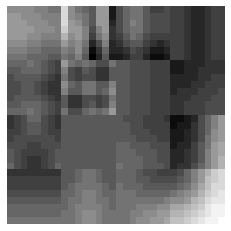

In [101]:
plt.imshow(img, cmap="gray")
plt.axis("off")

In [102]:
def dft(image):
    m, n = image.shape
    res = np.zeros((m, n), dtype=complex)
    for u in range(m):
        for v in range(n):
            s = 0j
            for x in range(m):
                for y in range(n):
                    angle = -2j * np.pi * ((u * x / m) + (v * y / n))
                    s += image[x, y] * np.exp(angle)
            res[u, v] = s / (m * n)
    return res

In [103]:
dft2d = dft(img)
mag = np.abs(dft2d)
log_mag = np.log(1 + mag)

(-0.5, 31.5, 31.5, -0.5)

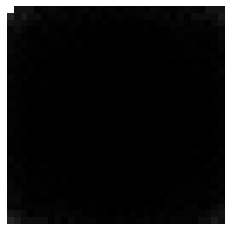

In [104]:
plt.imshow(log_mag, cmap="gray")
plt.axis("off")

In [105]:
phase = np.angle(dft2d)

(-0.5, 31.5, 31.5, -0.5)

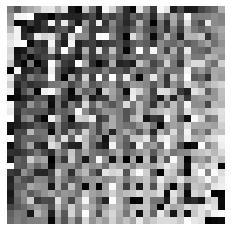

In [106]:
plt.imshow(phase, cmap="gray")
plt.axis("off")

In [107]:
def idft(image):
    m, n = image.shape
    res = np.zeros((m, n), dtype=complex)
    for x in range(m):
        for y in range(n):
            s = 0j
            for u in range(m):
                for v in range(n):
                    angle = 2j * np.pi * ((u * x / m) + (v * y / n))
                    s += image[u, v] * np.exp(angle)
            res[x, y] = s 
    return np.real(res)

In [108]:
res = idft(dft2d)

(-0.5, 31.5, 31.5, -0.5)

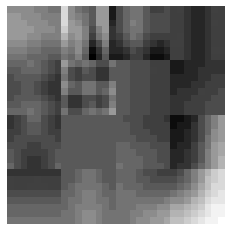

In [109]:
plt.imshow(res, cmap="gray")
plt.axis("off")

### Q2

In [110]:
def dft_basis(m, n, u, v):
    r = np.zeros((m, n))
    i = np.zeros((m, n))
    for x in range(m):
        for y in range(n):
            angle = -2 * np.pi * ((u * x / m) + (v * y / n))
            r[x, y] = np.cos(angle)
            i[x, y] = np.sin(angle)

    return r, i

def plot_basis_grid(m=8, n=8):
    fig, axes = plt.subplots(m, n*2, figsize=(2*n, 2*m))
    for u in range(m):
        for v in range(n):
            real, imag = dft_basis(m, n, u, v)
            ax_real = axes[u, 2*v]
            ax_real.imshow(real, cmap='gray')
            ax_real.set_title(f"R({u},{v})", fontsize=6)
            ax_real.axis('off')
            ax_imag = axes[u, 2*v + 1]
            ax_imag.imshow(imag, cmap='gray')
            ax_imag.set_title(f"I({u},{v})", fontsize=6)
            ax_imag.axis('off')
    plt.tight_layout()
    plt.show()

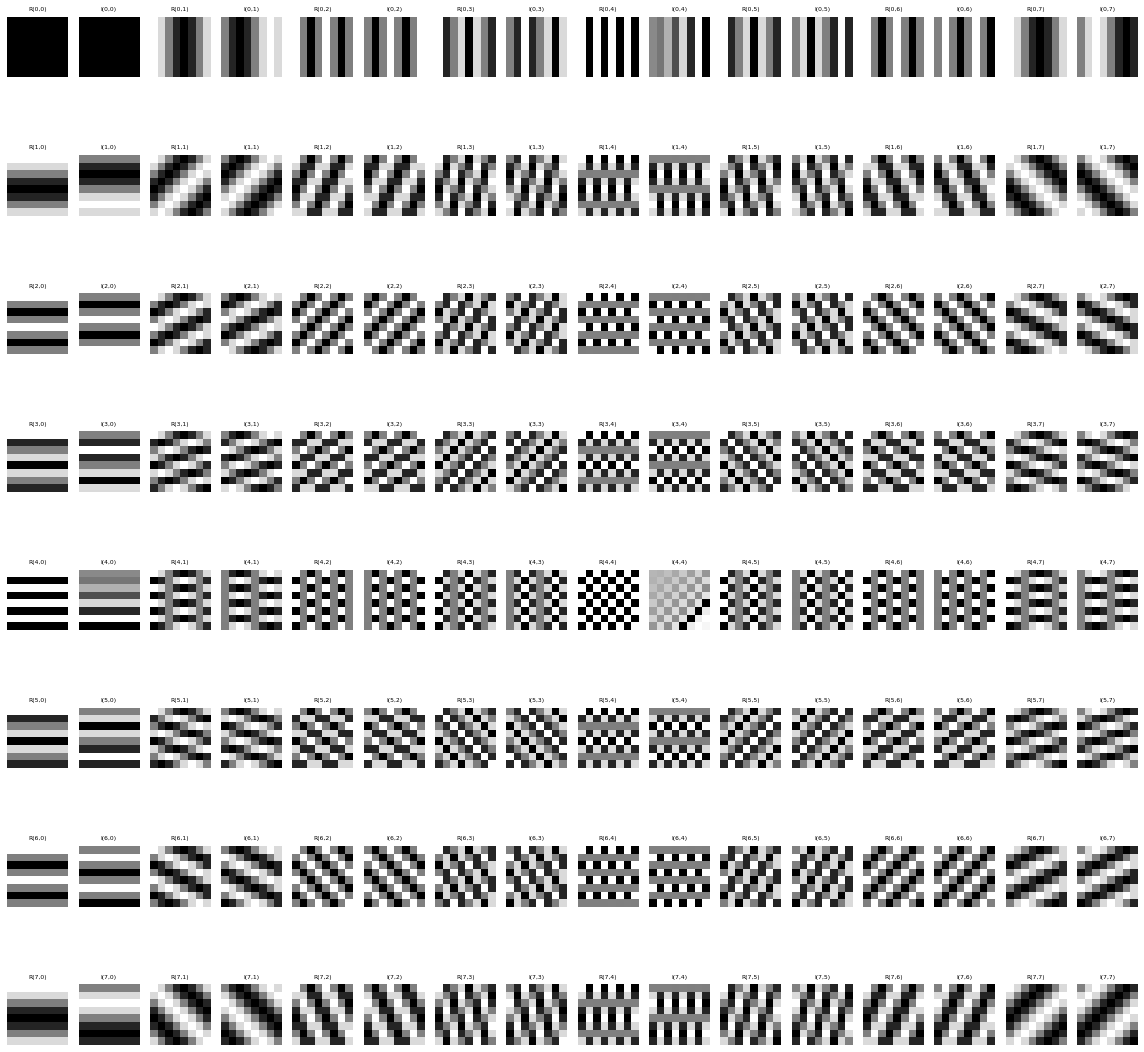

In [111]:
plot_basis_grid(8, 8)

### Q3

(-0.5, 31.5, 31.5, -0.5)

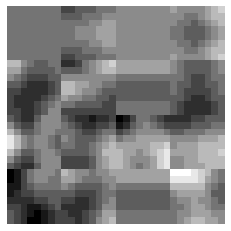

In [114]:
img1 = plt.imread('2.jpg')
if len(img1.shape) == 3:
    img1 = np.mean(img1, axis=2)
img1 = img1[:32, :32]
plt.imshow(img1, cmap="gray")
plt.axis("off")

(-0.5, 31.5, 31.5, -0.5)

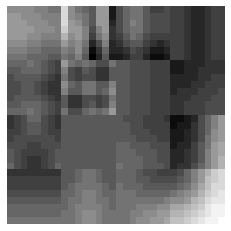

In [115]:
img2 = plt.imread('3.jpg')
if len(img2.shape) == 3:
    img2 = np.mean(img2, axis=2)
img2 = img2[:32, :32]
plt.imshow(img2, cmap="gray")
plt.axis("off")

In [116]:
f1 = dft(img1)
f2 = dft(img2)

In [120]:
m1, p1 = np.abs(f1), np.angle(f1)
m2, p2 = np.abs(f2), np.angle(f2)

In [121]:
fn1 = m1 * np.exp(1j + p2)
fn2 = m2 * np.exp(1j + p1)

In [122]:
imgn1 = idft(fn1)
imgn2 = idft(fn2)

(-0.5, 31.5, 31.5, -0.5)

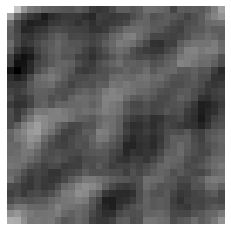

In [123]:
plt.imshow(imgn1, cmap="gray")
plt.axis("off")

(-0.5, 31.5, 31.5, -0.5)

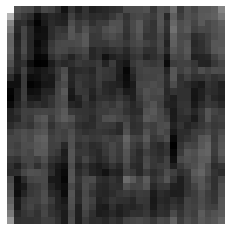

In [124]:
plt.imshow(imgn2, cmap="gray")
plt.axis("off")